In [ ]:
import yfinance as yf

ticker_symbol = '^IXIC'
start_date = '2019-01-01'

nasdaq_data = yf.download(ticker_symbol, start=start_date)

print("NASDAQ Composite Index data downloaded successfully.")
print(nasdaq_data.head())

print('Missing values per column:')
display(nasdaq_data.isnull().sum())

print('\nTotal rows:', nasdaq_data.shape[0])
print('Total columns:', nasdaq_data.shape[1])



/tmp/ipython-input-2684802224.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nasdaq_data = yf.download(ticker_symbol, start=start_date)
[*********************100%***********************]  1 of 1 completed

NASDAQ Composite Index data downloaded successfully.
Price             Close         High          Low         Open      Volume
Ticker            ^IXIC        ^IXIC        ^IXIC        ^IXIC       ^IXIC
Date                                                                      
2019-01-02  6665.939941  6693.709961  6506.879883  6506.910156  2261800000
2019-01-03  6463.500000  6600.209961  6457.129883  6584.770020  2631550000
2019-01-04  6738.859863  6760.689941  6554.240234  6567.140137  2596150000
2019-01-07  6823.470215  6855.600098  6741.399902  6757.529785  2523450000
2019-01-08  6897.000000  6909.580078  6795.859863  6893.439941  2407340000
Missing values per column:


,,0
Price,Ticker,
Close,^IXIC,0
High,^IXIC,0
Low,^IXIC,0
Open,^IXIC,0
Volume,^IXIC,0



Total rows: 1795
Total columns: 5


In [ ]:
import pandas as pd
from prophet import Prophet


nasdaq_data.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in nasdaq_data.columns.values]


prophet_df = nasdaq_data[['Close_^IXIC']].copy()
prophet_df.columns = ['price']


train_size = int(len(prophet_df) * 0.8)
train = prophet_df.iloc[:train_size]
test = prophet_df.iloc[train_size:]

prophet_train = pd.DataFrame({
    'ds': train.index,
    'y': train['price'].values
  })

print("Fitting Prophet model...")
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10.0
)

prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=len(test), freq='D')

forecast = prophet_model.predict(future)

forecast.set_index('ds', inplace=True)

forecast_test = forecast.reindex(test.index).copy()

forecast_test = forecast_test.dropna()

Fitting Prophet model...


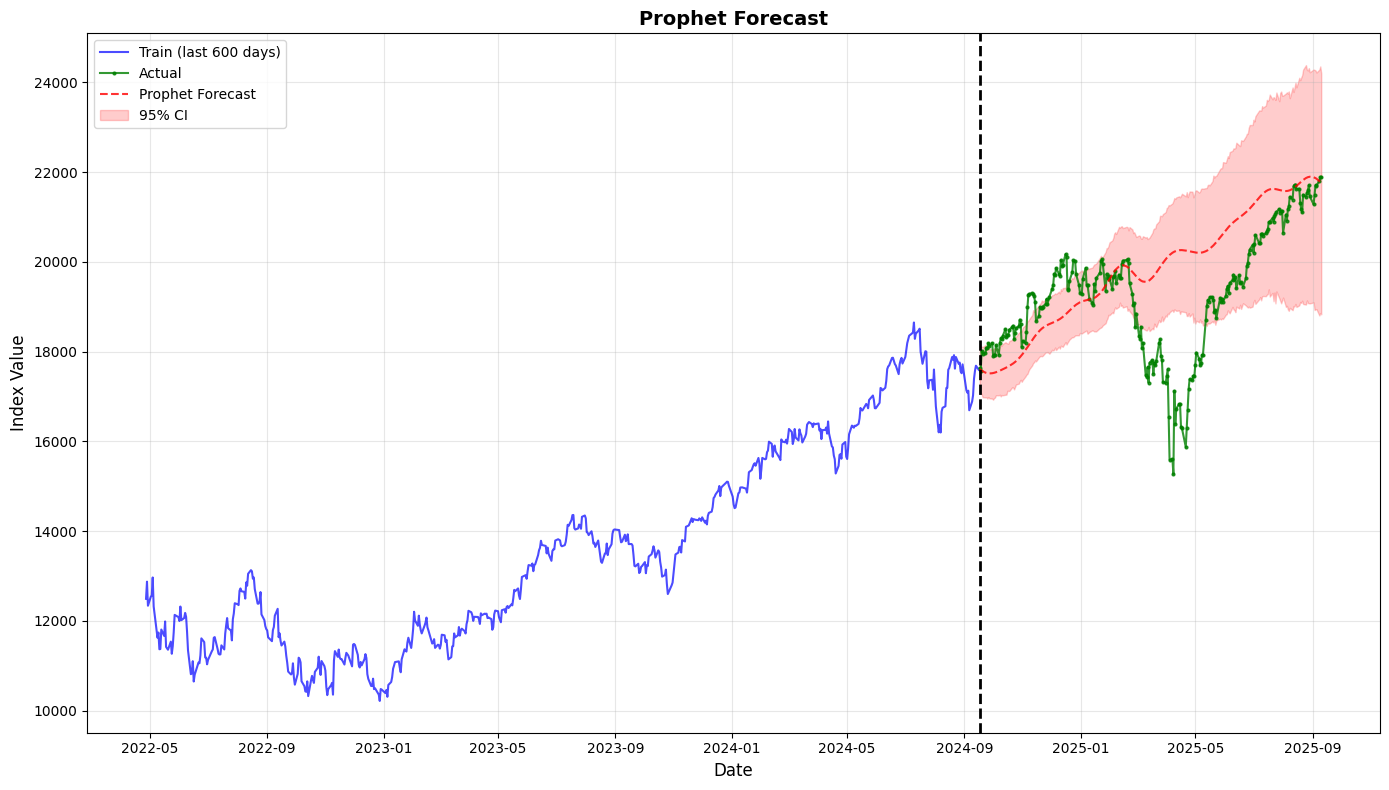

In [ ]:
import matplotlib.pyplot as plt

split_date = test.index.min()

fig, ax = plt.subplots(1, 1, figsize=(14, 8))

ax.plot(train.index[-600:], train['price'][-600:], linewidth=1.5, alpha=0.7,
        color='blue', label='Train (last 600 days)')
aligned_test_plot = test.reindex(forecast_test.index).dropna()
ax.plot(aligned_test_plot.index, aligned_test_plot['price'], linewidth=1.5, alpha=0.8,
        color='green', label='Actual', marker='o', markersize=2)
ax.plot(forecast_test.index, forecast_test['yhat'], linewidth=1.5, alpha=0.8,
        color='red', linestyle='--', label='Prophet Forecast')
ax.fill_between(forecast_test.index,
                 forecast_test['yhat_lower'],
                 forecast_test['yhat_upper'],
                 alpha=0.2, color='red', label='95% CI')
ax.axvline(x=split_date, color='black', linestyle='--', linewidth=2)
ax.set_title('Prophet Forecast', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Index Value', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import datetime
import pandas as pd


today = datetime.date.today()


future_dates_list = []
current_date = today
while len(future_dates_list) < 5:
    current_date += datetime.timedelta(days=1)

    future_dates_list.append(current_date)

future_5_days_from_today = pd.DataFrame({'ds': future_dates_list})


forecast_5_days_from_today = prophet_model.predict(future_5_days_from_today)

print(f"5-day ahead forecast for NASDAQ starting from {today + datetime.timedelta(days=1)}:")
display(forecast_5_days_from_today[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])

5-day ahead forecast for NASDAQ starting from 2026-02-25:


,ds,yhat,yhat_lower,yhat_upper
0,2026-02-25,23757.735028,23201.672872,24324.703636
1,2026-02-26,23732.677794,23184.370297,24265.720012
2,2026-02-27,23707.778470,23183.162507,24220.859434
3,2026-02-28,23683.477364,23140.238407,24221.230171
4,2026-03-01,23660.201008,23097.873610,24222.610369
